### 04 -- XGBoost Tuning with MLflow Tracking

Replace the logistic regression baseline with XGBoost.
Tune hyperparameters with Optuna, log every trial to MLflow,
then explain the best model with SHAP.

import os
from dotenv import load_dotenv
import dagshub

load_dotenv()  # loads .env from project root

dagshub.init(
    repo_owner=os.environ.get("DAGSHUB_REPO_OWNER", "Zuleikha"),
    repo_name=os.environ.get("DAGSHUB_REPO_NAME", "fraud-detection-ML-project"),
    mlflow=True,
)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
)

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_TRIALS     = 50
CV_FOLDS     = 3
MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

## 1. Load & prep

In [18]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# XGBoost handles scale internally but we keep the ratio for scale_pos_weight
neg, pos        = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}  ({neg:,} legit / {pos} fraud in train)")

scale_pos_weight = 577.3  (227,451 legit / 394 fraud in train)


## 2. XGBoost baseline (no tuning)

Establish the out-of-the-box score before Optuna touches anything.

In [20]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
base_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

base_prob  = base_xgb.predict_proba(X_test)[:, 1]
base_prauc = average_precision_score(y_test, base_prob)
print(f"Baseline XGBoost PR-AUC : {base_prauc:.4f}")

Baseline XGBoost PR-AUC : 0.8823


## 3. Hyperparameter tuning with Optuna + MLflow

Each Optuna trial is logged as a child run under the parent MLflow experiment.
CV is stratified so every fold sees representative fraud counts.

In [22]:
mlflow.set_experiment('fraud-xgboost-tuning')

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'scale_pos_weight'  : scale_pos_weight,
        'eval_metric'       : 'aucpr',
        'random_state'      : RANDOM_STATE,
        'use_label_encoder' : False,
    }

    fold_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        Xf_tr, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf_tr, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        m = xgb.XGBClassifier(**params)
        m.fit(Xf_tr, yf_tr, verbose=False)
        fold_scores.append(average_precision_score(yf_val, m.predict_proba(Xf_val)[:, 1]))

    mean_prauc = float(np.mean(fold_scores))

    with mlflow.start_run(nested=True):
        mlflow.log_params(params)
        mlflow.log_metric('cv_pr_auc', mean_prauc)

    return mean_prauc


with mlflow.start_run(run_name='optuna-parent'):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_metric('best_cv_pr_auc', study.best_value)
    mlflow.log_params(study.best_params)

print(f"\nBest CV PR-AUC : {study.best_value:.4f}")
print(f"Best params    : {study.best_params}")

2026/05/22 11:44:49 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 11:44:49 INFO mlflow.store.db.utils: Updating database tables
2026/05/22 11:45:08 INFO mlflow.tracking.fluent: Experiment with name 'fraud-xgboost-tuning' does not exist. Creating a new experiment.


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV PR-AUC : 0.8518
Best params    : {'n_estimators': 545, 'max_depth': 5, 'learning_rate': 0.09739928061541073, 'subsample': 0.7124476849665192, 'colsample_bytree': 0.610652916684024, 'min_child_weight': 7, 'gamma': 0.5314641856644291, 'reg_alpha': 0.5748237963432712, 'reg_lambda': 0.272582374919218}


## 4. Retrain best params on full training set

In [24]:
best_params = study.best_params | {
    'scale_pos_weight' : scale_pos_weight,
    'eval_metric'      : 'aucpr',
    'random_state'     : RANDOM_STATE,
}

best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train, verbose=False)

y_prob  = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= 0.5).astype(int)
prauc   = average_precision_score(y_test, y_prob)
rocauc  = roc_auc_score(y_test, y_prob)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print(f"Tuned XGBoost PR-AUC  : {prauc:.4f}  (baseline was {base_prauc:.4f})")
print(f"Tuned XGBoost ROC-AUC : {rocauc:.4f}")
print(f"Precision             : {prec:.4f}")
print(f"Recall                : {rec:.4f}")
print(f"F1                    : {f1:.4f}")

Tuned XGBoost PR-AUC  : 0.8782  (baseline was 0.8823)
Tuned XGBoost ROC-AUC : 0.9804
Precision             : 0.8454
Recall                : 0.8367
F1                    : 0.8410


## 5. Confusion matrix

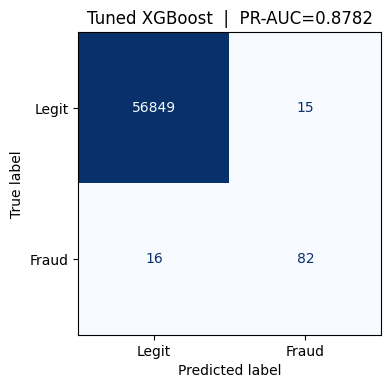

Fraud caught (TP) : 82
Fraud missed (FN) : 16
False alarms (FP) : 15
Correct legit (TN): 56,849


In [26]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Tuned XGBoost  |  PR-AUC={prauc:.4f}')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Fraud caught (TP) : {tp}")
print(f"Fraud missed (FN) : {fn}")
print(f"False alarms (FP) : {fp}")
print(f"Correct legit (TN): {tn:,}")

## 6. SHAP explainability (overview)

Quick global feature importance using SHAP.
Notebook 05 covers SHAP in full depth (beeswarm, waterfall, dependence plots).

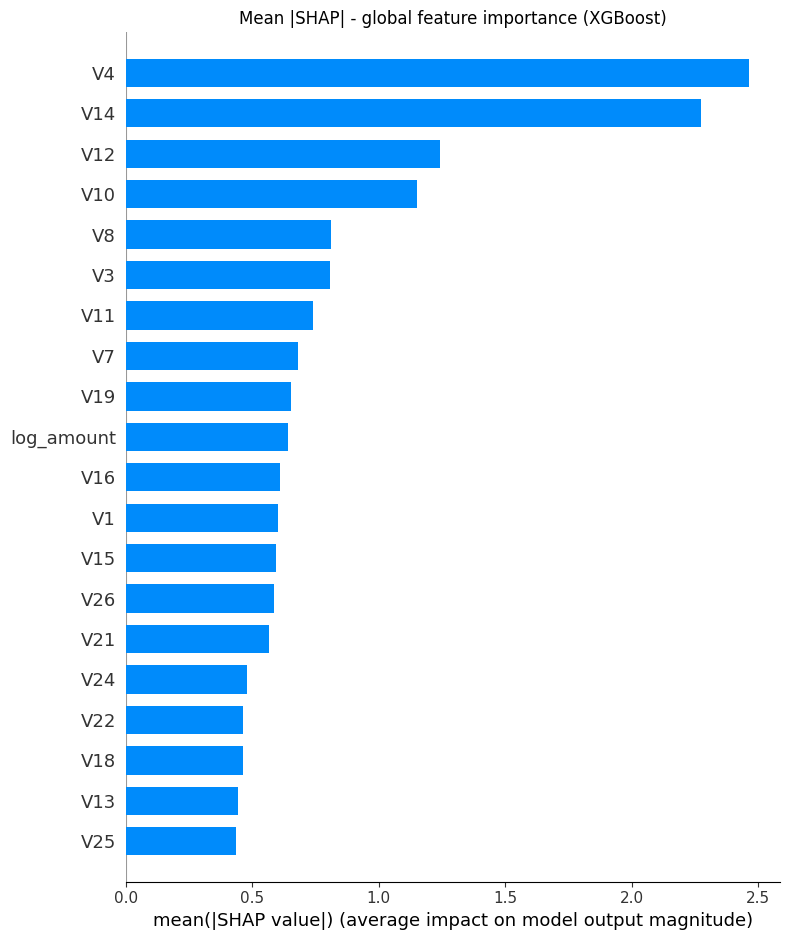

Top 5 fraud signals (SHAP):
  V4        mean |SHAP|=2.4628
  V14       mean |SHAP|=2.2725
  V12       mean |SHAP|=1.2413
  V10       mean |SHAP|=1.1529
  V8        mean |SHAP|=0.8128


In [28]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean |SHAP| - global feature importance (XGBoost)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

mean_shap_04 = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
print("Top 5 fraud signals (SHAP):")
for feat, score in mean_shap_04.head(5).items():
    print(f"  {feat:8s}  mean |SHAP|={score:.4f}")

## 7. Save model and log final run to MLflow

## joblib.dump(best_model, MODELS_PATH / 'best_xgb.pkl')
print("Saved: outputs/models/best_xgb.pkl")

with mlflow.start_run(run_name='final-xgboost'):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'test_pr_auc' : prauc,
        'test_roc_auc': rocauc,
        'precision'   : prec,
        'recall'      : rec,
        'f1'          : f1,
    })
    mlflow.xgboost.log_model(best_model, name='model')

print("\n" + "=" * 55)
print("XGBOOST TUNING SUMMARY")
print("=" * 55)
print(f"  Baseline XGBoost PR-AUC  : {base_prauc:.4f}")
print(f"  Tuned XGBoost PR-AUC     : {prauc:.4f}")
print(f"  ROC-AUC                  : {rocauc:.4f}")
print(f"  Precision                : {prec:.4f}")
print(f"  Recall                   : {rec:.4f}")
print(f"  F1                       : {f1:.4f}")
print(f"  Fraud caught             : {tp} / {y_test.sum()} ({tp/y_test.sum()*100:.1f}%)")
print(f"  Fraud missed             : {fn}")
print(f"  Best params              : {study.best_params}")
print(f"\nNext: notebook 05 - SHAP explainability in full depth.")
print("=" * 55)